In [ ]:
pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 7.7 MB/s  0:00:02 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


# Data Fetch

In [ ]:
import pandas as pd

# Set chunk size
chunksize = 500000  # 500k rows per chunk
query = "SELECT * FROM transactions;"

# Use a generator to fetch in chunks
dfs = []
for chunk in pd.read_sql(query, engine, chunksize=chunksize):
    dfs.append(chunk)

# Combine all chunks into a single DataFrame
df = pd.concat(dfs, ignore_index=True)

# Check
print(df.shape)
df.head()

(6575790, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


# Basic Stats

In [25]:
# General statistics
df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']].describe()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,1.000000e+06,1.000000e+06,1.000000e+06,1.000000e+06,1.000000e+06
mean,1.674841e+05,8.777377e+05,8.976509e+05,9.764678e+05,1.148684e+06
std,2.814822e+05,2.916560e+06,2.953558e+06,2.329126e+06,2.495648e+06
min,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.279386e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,7.774828e+04,1.692600e+04,0.000000e+00,1.076115e+05,2.075764e+05
75%,2.222042e+05,1.549515e+05,1.960526e+05,8.870427e+05,1.183532e+06
max,1.000000e+07,3.893942e+07,3.894623e+07,4.148270e+07,4.205466e+07


# Fraud Count

In [26]:
df['isFraud'].value_counts()

isFraud
0    999392
1       608
Name: count, dtype: int64

# Fraud Rate

In [10]:
fraud_rate = df['isFraud'].mean()*100
print(round(fraud_rate, 2), "% of transactions are fraudulent.")


0.06 % of transactions are fraudulent.


# Fraud Dist by type

In [12]:
df.groupby("type")["isFraud"].sum()

type
CASH_IN       0
CASH_OUT    314
DEBIT         0
PAYMENT       0
TRANSFER    294
Name: isFraud, dtype: int64

Fraud happens only in "CASH_OUT" and "TRANSFER"

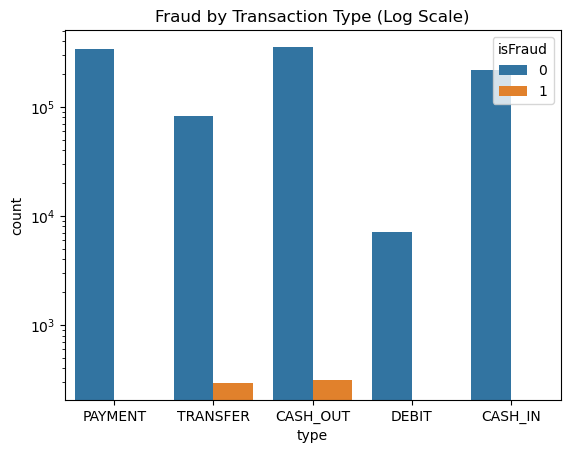

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='type', hue='isFraud', data=df)
plt.yscale("log")
plt.title("Fraud by Transaction Type (Log Scale)")
plt.show()

Fraudsters often: : TRANSFER → CASH_OUT i.e TRANSFER followed by CASH_OUT

# Transaction Amount Distribution

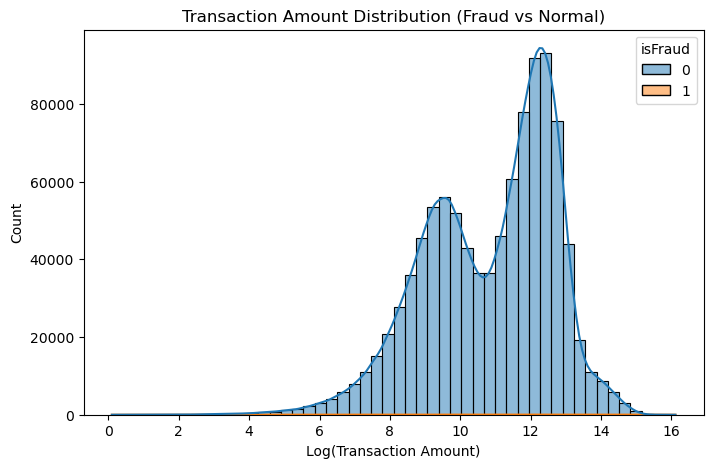

In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(data=df, x=np.log1p(df['amount']), hue='isFraud', bins=50, kde=True)

plt.title("Transaction Amount Distribution (Fraud vs Normal)")
plt.xlabel("Log(Transaction Amount)")
plt.show()

Fraud transactions generally occur at higher transaction values compared to normal transactions, suggesting attackers attempt to maximize gains per transaction.

## Transaction Amount vs Fraud

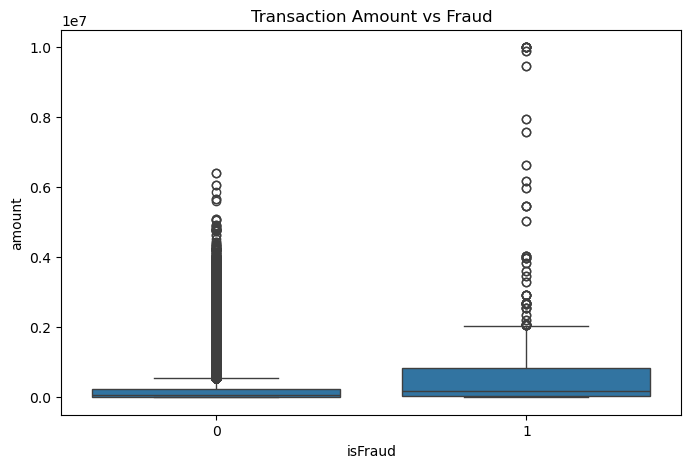

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(x='isFraud', y='amount', data=df)

plt.title("Transaction Amount vs Fraud")

plt.show()

Fraud transactions tend to have:

higher median

larger outliers

Meaning fraud transactions can be extreme values.

We may conclude :
large transfer + new account → suspicious

# Balance Before vs After Transaction

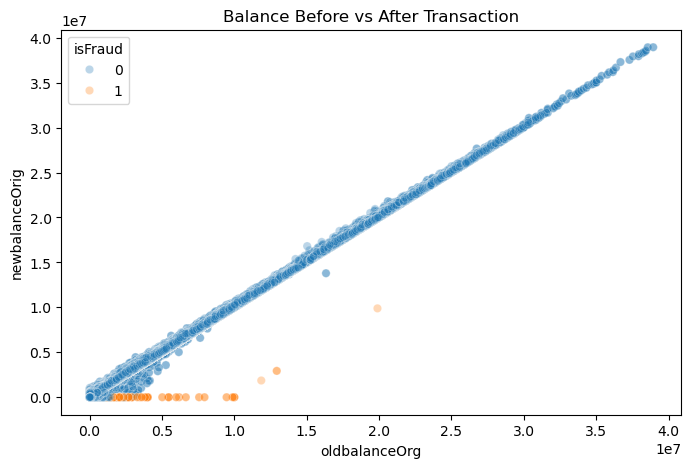

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='oldbalanceOrg', y='newbalanceOrig', hue='isFraud', data=df, alpha=0.3)

plt.title("Balance Before vs After Transaction")

plt.show()

Fraud transactions often show: old balance > 0
new balance = 0 i.e account emptied

# Destination Balance Check

In [29]:
df.groupby('isFraud')['oldbalanceDest'].mean()

isFraud
0    976793.391783
1    441317.534194
Name: oldbalanceDest, dtype: float64

# Time Pattern Analysis

Fraud sometimes happens in bursts.

Example:

Day 1 → few frauds

Day 2 → spike

Day 3 → spike

This indicates coordinated fraud attacks.

### Fraud per day

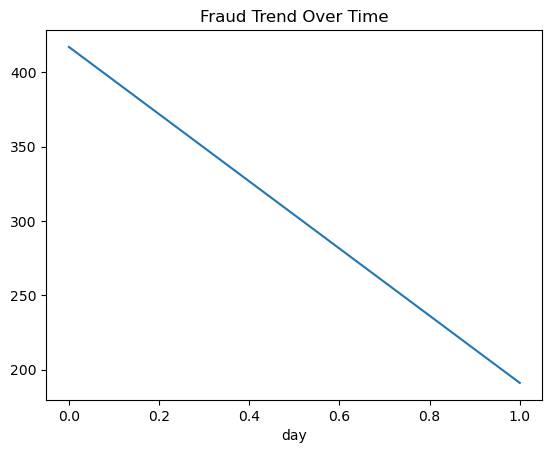

In [42]:
df['day'] = df['step'] // 24

fraud_by_day = df.groupby('day')['isFraud'].sum()

fraud_by_day.plot()

plt.title("Fraud Trend Over Time")

plt.show()

### Fraud Occurrence Over Time

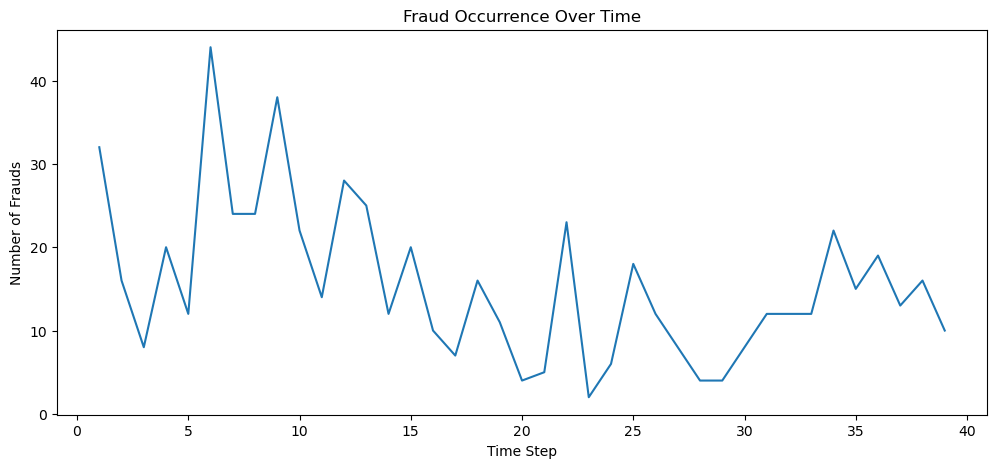

In [43]:
fraud_by_step = df.groupby('step')['isFraud'].sum()

plt.figure(figsize=(12,5))

fraud_by_step.plot()

plt.title("Fraud Occurrence Over Time")
plt.xlabel("Time Step")
plt.ylabel("Number of Frauds")

plt.show()

Fraud events tend to appear in clusters over time rather than being evenly distributed. This suggests coordinated fraud attempts where multiple fraudulent transactions occur within a short period.

# Z score Detection

Z-score formula:

z = (x - μ) / σ

Where

x = transaction amount
μ = mean amount
σ = standard deviation

In [34]:
from scipy import stats

df['z_score'] = stats.zscore(df['amount'])

### Suspicious Transactions

In [35]:
df[df['z_score'] > 3]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_error,day,z_score
85,1,TRANSFER,1505626.01,C926859124,0.00,0.0,C665576141,29031.00,5515763.34,0,0,-1505626.01,0,4.753915
89,1,TRANSFER,1429051.47,C1520267010,0.00,0.0,C1590550415,2041543.62,19169204.93,0,0,-1429051.47,0,4.481875
94,1,TRANSFER,1724887.05,C1495608502,0.00,0.0,C1590550415,3470595.10,19169204.93,0,0,-1724887.05,0,5.532867
358,1,TRANSFER,1538200.39,C476579021,0.00,0.0,C1590550415,6977445.38,19169204.93,0,0,-1538200.39,0,4.869640
359,1,TRANSFER,2421578.09,C106297322,0.00,0.0,C1590550415,8515645.77,19169204.93,0,0,-2421578.09,0,8.007949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999054,39,TRANSFER,1077220.87,C1490066622,1554.00,0.0,C1559376436,168226.84,1245447.72,0,0,-1075666.87,1,3.231953
999617,39,TRANSFER,1070818.37,C376294748,73126.00,0.0,C1957819571,0.00,1102303.05,0,0,-997692.37,1,3.209207
999774,39,TRANSFER,1747502.44,C194046440,61921.53,0.0,C2122868895,2271079.17,4018581.61,0,0,-1685580.91,1,5.613211
999938,39,TRANSFER,1779587.15,C516837161,23960.23,0.0,C224551757,2495250.79,4274837.94,0,0,-1755626.92,1,5.727196


Z-score analysis helps identify extreme transaction amounts relative to the overall dataset distribution, which can serve as a preliminary signal for suspicious activity.

# Fraud Pattern Discovery

### Fraud Amount Average

In [36]:
df.groupby('isFraud')['amount'].mean()

isFraud
0    167052.115505
1    877616.539391
Name: amount, dtype: float64

### Fraud Transaction Type

In [37]:
pd.crosstab(df['type'], df['isFraud'])

isFraud,0,1
type,,
CASH_IN,216023,0
CASH_OUT,354310,314
DEBIT,7126,0
PAYMENT,339430,0
TRANSFER,82503,294


### Fraud Balance Error

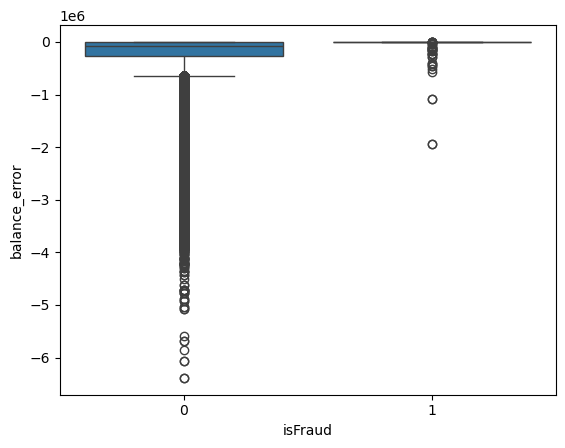

In [46]:
df['balance_error'] = (df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig'])  # This should be the error in the original account balance after the transaction
df.groupby('isFraud')['balance_error'].mean()

# Boxplot of balance error by fraud status

sns.boxplot(x='isFraud', y='balance_error', data=df)

plt.show()

Fraudulent transactions often exhibit balance inconsistencies, where the expected balance change does not match the transaction amount, indicating potential manipulation.

expected balance change --> Old Balance − Transaction Amount = New Balance

Any kind of deviation from this will show anomaly transactions which could be fraudulent

#### The analysis revealed that fraud transactions are extremely rare but are concentrated in TRANSFER and CASH_OUT transaction types. Fraud transactions often involve larger amounts and frequently show inconsistencies in account balance updates. Additionally, fraud events tend to occur in bursts over time, indicating coordinated fraudulent activity .


# Fraud Probability Analysis

In [48]:
fraud_rate = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)
print(fraud_rate)

type
TRANSFER    0.003551
CASH_OUT    0.000885
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


Instead of looking at fraud counts, I calculated the fraud probability for each transaction type.
This helps identify which transaction type is riskier relative to its volume.

Transfer transactions showed the highest fraud probability, indicating fraudsters prefer transferring money rather than regular payments.



# Fraud Amount Threshold

In [49]:
df.groupby('isFraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,999392.0,167052.115505,2.775183e+05,0.1,12788.8525,77709.58,222100.25,6419835.27
1,608.0,877616.539391,1.795051e+06,119.0,25071.4600,180967.56,838027.79,10000000.00


Fraud transactions show significantly higher average and median transaction amounts compared to normal transactions. This suggests that fraudsters tend to perform high-value transfers to maximize financial gain.

# Correlation Analysis

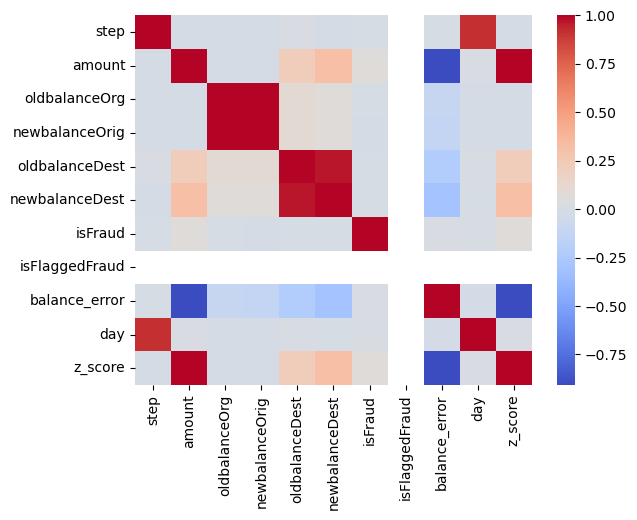

In [50]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm')
plt.show()

Correlation analysis shows strong relationships between balance variables such as oldbalanceOrg and newbalanceOrig, which is expected since account balances update after transactions.

However, fraud does not show strong correlation with individual variables, suggesting that fraud detection requires combining multiple behavioral features rather than relying on a single variable.


# Rule-Based Fraud Detection

In [51]:
df['rule_flag'] = (
    (df['type'].isin(['TRANSFER','CASH_OUT'])) &
    (df['amount'] > 200000) &
    (df['balance_error'] != 0)
)

Based on the exploratory analysis, I created a rule-based fraud flag combining high transaction amount, transfer-based transactions, and balance inconsistencies

In [54]:
df['fraud_risk'] = (
    (df['type'].isin(['TRANSFER','CASH_OUT'])).astype(int) +
    (df['amount'] > 200000).astype(int) +
    (df['balance_error'] != 0).astype(int)
)
df['fraud_risk'].value_counts()



fraud_risk
1    380841
2    291008
3    200704
0    127447
Name: count, dtype: int64